# Assignment 3: Time Series Analysis
### Classifying Cardiac Arrhythmias with the MIT-BIH Arrhythmia Database
---

## Task 1: Data Loading & Exploration


## 1.0 Library Imports & Versions

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PhysioNet data access
import wfdb

# Scikit-learn utilities
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from collections import Counter
import joblib
import os
import torch
from torch.utils.data import Dataset, DataLoader

# Reproducibility
np.random.seed(42)

---
## 1.1 Dataset Overview

### MIT-BIH Arrhythmia Database

The **MIT-BIH Arrhythmia Database** (PhysioNet) is a widely studied biomedical signal datasets. It contains:
- **48 recordings** of two-channel ambulatory ECG, each ~30 minutes long
- Digitised at **360 Hz** with 11-bit resolution over a ±5 mV range
- Each beat annotated by **two cardiologists** with a symbol indicating the beat type

We will work with the **14-record subset** specified in the assignment, which provides a representative mix of normal rhythm and clinically significant arrhythmias.

### AAMI 3-Class Mapping

The raw annotation files contain over 15 distinct beat symbols. We map these to a **3-class scheme**:

| Class | Meaning | Raw symbols |
|---|---|---|
| **N** | Normal / bundle branch | `N`, `.`, `L`, `R`, `e`, `j` |
| **S** | Supraventricular ectopic | `A`, `a`, `J`, `S` |
| **V** | Ventricular ectopic | `V`, `E` |
| — | Discarded | All other symbols (pacemaker, noise, rhythm annotations) |

In [2]:
# Configuration

RECORDS = ['100', '101', '105', '106', '108', '109', '111',
           '112', '115', '117', '119', '201', '213', '219']

FS        = 360    # sampling rate (Hz) — fixed for MIT-BIH
N_RECORDS = len(RECORDS)
SEED      = 42     # random state for all splits
T_WINDOW  = 10     # sliding window length in beats (for RNN / LSTM)

FEATURE_COLS = [
    'RR_current', 'RR_prev', 'RR_ratio', 'RR_local_mean',
    'R_amplitude', 'QRS_duration', 'QRS_energy', 'ST_mean'
]

# AAMI 3-class label map (as specified in the assignment)
LABEL_MAP = {
    # N: Normal
    'N': 'N', '.': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    # S: Supraventricular ectopic
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    # V: Ventricular ectopic
    'V': 'V', 'E': 'V',
}

# Colour palette consistent across all plots
CLASS_COLORS = {'N': '#2196F3', 'S': '#FF9800', 'V': '#F44336'}

print(f"Records to load  : {N_RECORDS}")
print(f"Records           : {', '.join(RECORDS)}")
print(f"Sampling rate     : {FS} Hz")
print(f"Window size (T)   : {T_WINDOW} beats")
print(f"Random seed       : {SEED}")
print(f"Mapped classes    : N (Normal), S (Supraventricular), V (Ventricular)")


Records to load  : 14
Records           : 100, 101, 105, 106, 108, 109, 111, 112, 115, 117, 119, 201, 213, 219
Sampling rate     : 360 Hz
Window size (T)   : 10 beats
Random seed       : 42
Mapped classes    : N (Normal), S (Supraventricular), V (Ventricular)


---
## Train / Test Split Strategy: Temporal Intra-Patient Split

We split each record **temporally**: the first 80% of beats go to training,
the last 20% to test. This is applied independently per record.

This avoids the window-overlap leakage of a pure random split (consecutive windows
share 9 out of 10 beats, so a random split would place nearly-identical windows in
both train and test) while keeping the intra-patient setting that allows the model
to learn each patient's baseline rhythm before being tested on their later beats.


---
## 1.2 Load All 14 Records

We iterate over all 14 records, loading:
- The ECG signal (channel 0, MLII lead)
- The annotation file (R-peak positions + beat symbols)

We apply `LABEL_MAP` immediately, discarding any unmapped symbols.

In [3]:
# Load all records

records_data = {}   # dict: record_id: {'signal': ..., 'r_peaks': ..., 'labels': ...}
load_summary = []   # for the summary table

total_discarded = 0
discarded_detail = {}  # record: count of discarded beats

for rec_id in RECORDS:
    # Download record and annotations from PhysioNet
    record = wfdb.rdrecord(rec_id, pn_dir='mitdb')
    ann    = wfdb.rdann(rec_id,    'atr', pn_dir='mitdb')

    signal   = record.p_signal[:, 0]   # channel 0 (MLII lead)
    r_peaks  = ann.sample               # R-peak sample indices
    symbols  = ann.symbol               # raw beat labels

    # Apply label_map, keeping only mapped beats
    mapped_labels, mapped_peaks = [], []
    n_discarded = 0

    for peak, sym in zip(r_peaks, symbols):
        if sym in LABEL_MAP:
            mapped_labels.append(LABEL_MAP[sym])
            mapped_peaks.append(peak)
        else:
            n_discarded += 1

    mapped_labels = np.array(mapped_labels)
    mapped_peaks  = np.array(mapped_peaks)

    total_discarded          += n_discarded
    discarded_detail[rec_id]  = n_discarded

    records_data[rec_id] = {
        'signal' : signal,
        'r_peaks': mapped_peaks,
        'labels' : mapped_labels,
        'fs'     : record.fs,
        'sig_name': record.sig_name,
        'duration_s': len(signal) / record.fs,
    }

    n_counts = {c: int(np.sum(mapped_labels == c)) for c in ['N', 'S', 'V']}
    load_summary.append({
        'Record'    : rec_id,
        'Duration (s)': round(len(signal) / record.fs, 1),
        'Total beats': len(mapped_labels),
        'N'         : n_counts['N'],
        'S'         : n_counts['S'],
        'V'         : n_counts['V'],
        'Discarded' : n_discarded,
    })

# Summary table
df_summary = pd.DataFrame(load_summary)
df_summary_totals = df_summary.copy()
totals = df_summary.select_dtypes(include='number').sum()
totals['Record'] = 'TOTAL'
totals['Duration (s)'] = round(totals['Duration (s)'], 1)
df_summary_totals = pd.concat([df_summary, pd.DataFrame([totals])], ignore_index=True)

print(f"\n{'='*65}")
print(f" Records loaded: {N_RECORDS}  |  Total beats discarded: {total_discarded}")
print(f"{'='*65}")
df_summary_totals


 Records loaded: 14  |  Total beats discarded: 1057


,Record,Duration (s),Total beats,N,S,V,Discarded
0,100,1805.6,2273.0,2239.0,33.0,1.0,1.0
1,101,1805.6,1863.0,1860.0,3.0,0.0,11.0
2,105,1805.6,2567.0,2526.0,0.0,41.0,124.0
3,106,1805.6,2027.0,1507.0,0.0,520.0,71.0
4,108,1805.6,1761.0,1740.0,4.0,17.0,63.0
5,109,1805.6,2530.0,2492.0,0.0,38.0,5.0
6,111,1805.6,2124.0,2123.0,0.0,1.0,9.0
7,112,1805.6,2539.0,2537.0,2.0,0.0,11.0
8,115,1805.6,1953.0,1953.0,0.0,0.0,9.0
9,117,1805.6,1535.0,1534.0,1.0,0.0,4.0


In [4]:
# Global beat counts

all_labels = np.concatenate([records_data[r]['labels'] for r in RECORDS])

n_N = int(np.sum(all_labels == 'N'))
n_S = int(np.sum(all_labels == 'S'))
n_V = int(np.sum(all_labels == 'V'))
n_total = len(all_labels)

print("Global beat counts across all 14 records:")
print(f"  N (Normal)            : {n_N:>6,d}  ({100*n_N/n_total:.1f}%)")
print(f"  S (Supraventricular)  : {n_S:>6,d}  ({100*n_S/n_total:.1f}%)")
print(f"  V (Ventricular)       : {n_V:>6,d}  ({100*n_V/n_total:.1f}%)")
print(f"  ─────────────────────────────────────")
print(f"  TOTAL (kept)          : {n_total:>6,d}")
print(f"  Discarded             : {total_discarded:>6,d}")

Global beat counts across all 14 records:
  N (Normal)            : 28,412  (94.2%)
  S (Supraventricular)  :    206  (0.7%)
  V (Ventricular)       :  1,544  (5.1%)
  ─────────────────────────────────────
  TOTAL (kept)          : 30,162
  Discarded             :  1,057


---
## 1.3 ECG Signal Visualisation

We plot **5-second segments** of the raw ECG signal for two records — one predominantly normal, one with notable arrhythmias. R-peak positions are marked and beat types annotated.

In [5]:
def plot_ecg_segment(record_id, start_sec=5.0, duration_sec=5.0):
    """
    Plot a segment of the ECG signal with R-peak markers and beat-type annotations.

    Parameters
    ----------
    record_id   : str    MIT-BIH record identifier (e.g. '100')
    start_sec   : float  Start of segment in seconds
    duration_sec: float  Duration of segment in seconds
    """

    data    = records_data[record_id]
    signal  = data['signal']
    r_peaks = data['r_peaks']
    labels  = data['labels']
    fs      = data['fs']

    start_sample = int(start_sec * fs)
    end_sample   = min(int((start_sec + duration_sec) * fs), len(signal))

    t_axis = np.arange(start_sample, end_sample) / fs
    seg    = signal[start_sample:end_sample]

    mask       = (r_peaks >= start_sample) & (r_peaks < end_sample)
    seg_peaks  = r_peaks[mask]
    seg_labels = labels[mask]

    fig, ax = plt.subplots(figsize=(14, 4))

    ax.plot(t_axis, seg, color='#1a1a2e', linewidth=0.9, alpha=0.85, label='ECG (MLII)')

    for cls in ['N', 'S', 'V']:
      cls_mask  = seg_labels == cls
      cls_peaks = seg_peaks[cls_mask]
      cls_amps  = signal[cls_peaks]
      cls_times = cls_peaks / fs
      ax.scatter(cls_times, cls_amps,
                 color=CLASS_COLORS[cls], zorder=5, s=60, marker='^',
                 label=f'{cls} beat ({cls_mask.sum()})',
                 edgecolors='white', linewidths=0.5)
      for t_pk, amp_pk, lbl in zip(cls_times, cls_amps, seg_labels[cls_mask]):
          ax.text(t_pk, amp_pk + 0.12, lbl,
                  ha='center', va='bottom', fontsize=8,
                  color=CLASS_COLORS[cls], fontweight='bold')

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Amplitude (mV)', fontsize=11)
    ax.set_title(
      f'Record {record_id}: 5-second ECG segment '
      f'[{start_sec:.0f}s – {start_sec+duration_sec:.0f}s] ',
      fontsize=11, fontweight='bold'
    )
    ax.set_xlim(t_axis[0], t_axis[-1])
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.2))
    ax.grid(True, which='minor', alpha=0.1)
    plt.tight_layout()
    plt.show()



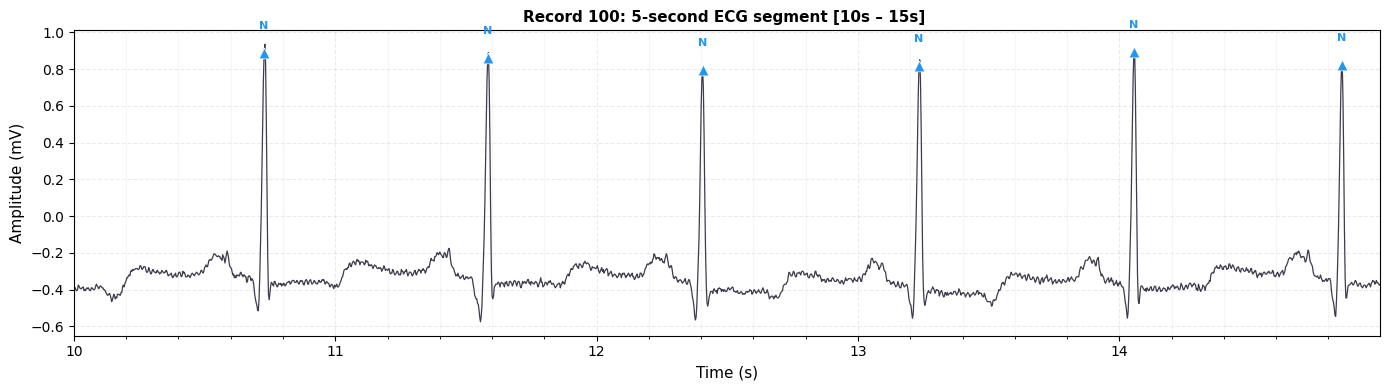

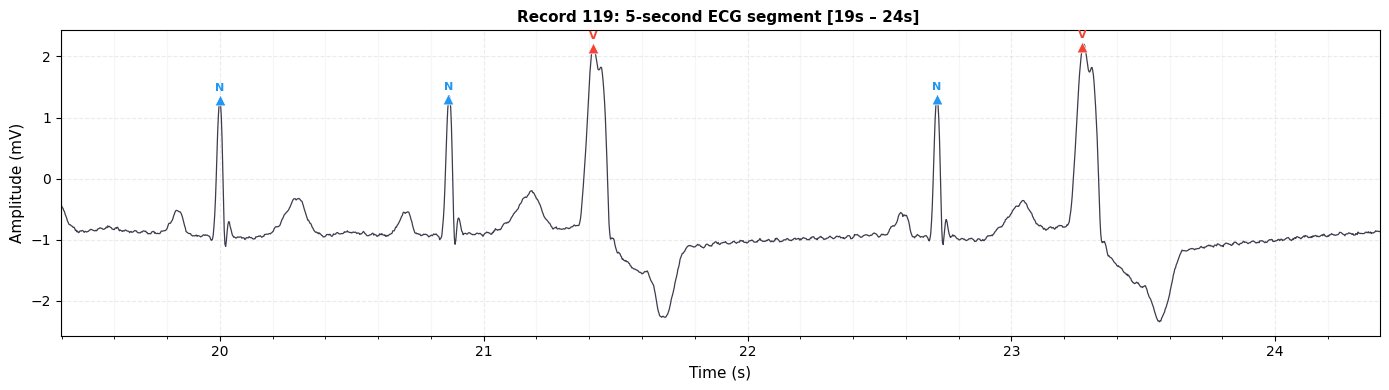

In [6]:
# Plot 1: Record 100
plot_ecg_segment('100', start_sec=10, duration_sec=5)

# Plot 2: Record 119
data_119 = records_data['119']
v_peaks  = data_119['r_peaks'][data_119['labels'] == 'V']
start_v  = max(0, v_peaks[3] / FS - 2)

plot_ecg_segment('119', start_sec=round(start_v, 1), duration_sec=5)


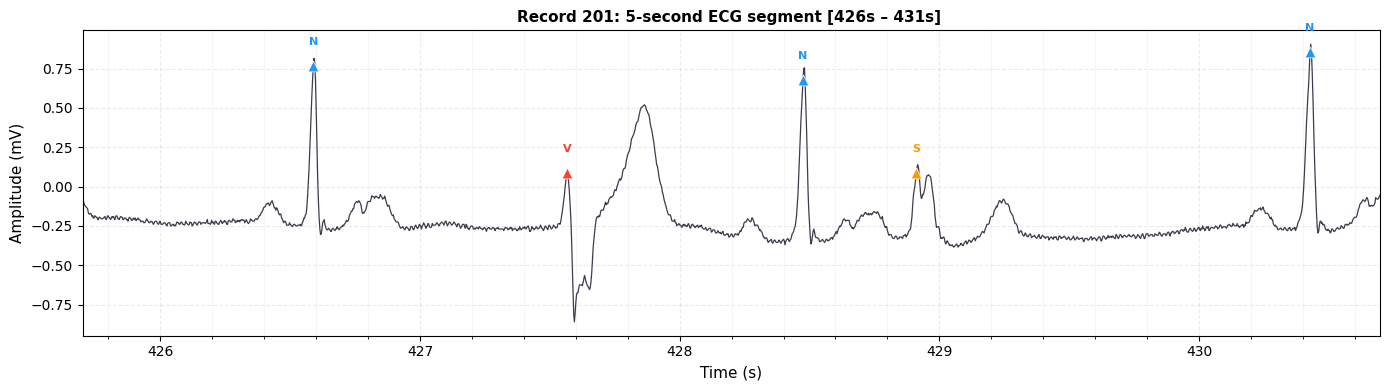

In [7]:
d_201  = records_data['201']
lbl_201 = d_201['labels']
pks_201 = d_201['r_peaks']
v_pks  = pks_201[lbl_201 == 'V']
s_pks  = pks_201[lbl_201 == 'S']

HALF_WIN_S = int(2.5 * FS)

start_201 = None
for vp in v_pks:
  nearby_s = s_pks[(s_pks > vp - HALF_WIN_S) & (s_pks < vp + HALF_WIN_S)]
  if len(nearby_s) > 0:
      centre    = int((vp + nearby_s[0]) // 2)
      start_201 = max(0.0, (centre - HALF_WIN_S) / FS)
      break

if start_201 is None:
  start_201 = max(0.0, v_pks[0] / FS - 2)

plot_ecg_segment('201', start_sec=round(start_201, 1), duration_sec=5)


We plot **5-second segments** of the raw ECG signal for three records, with R-peak
positions marked and beat types annotated.

**Record 100** shows only N beats, evenly spaced and with consistent amplitude and regular rhythm with no arrhythmias in this segment.

**Record 119** shows a mix of N and V beats. The V beats are visually distinct:
they arrive earlier than the surrounding N beats and have a noticeably different
shape and higher amplitude.

**Record 201** shows all three classes within a single 5-second window. The V beat
looks clearly different from the N beats in both shape and amplitude. The S beat is
also visually distinct, it is much smaller and rounder than the sharp N peaks,
making all three classes visually separable in this segment.

---
## 1.4 Class Distribution Analysis

We report the total number of beats per class and produce a bar chart showing the distribution across all 14 records.

In [8]:
# Per-record and global class distribution

df_dist = pd.DataFrame(load_summary).set_index('Record')[['N', 'S', 'V', 'Total beats']]

# Add percentage columns
for cls in ['N', 'S', 'V']:
    df_dist[f'{cls}%'] = (df_dist[cls] / df_dist['Total beats'] * 100).round(1)

print("Beat counts per class per record:")
print(df_dist.to_string())
print("\nGlobal totals:")
print(f"  N: {n_N:,} ({100*n_N/n_total:.2f}%)")
print(f"  S: {n_S:,} ({100*n_S/n_total:.2f}%)")
print(f"  V: {n_V:,} ({100*n_V/n_total:.2f}%)")
print(f"  Total: {n_total:,}")

Beat counts per class per record:
           N    S    V  Total beats     N%   S%    V%
Record                                               
100     2239   33    1         2273   98.5  1.5   0.0
101     1860    3    0         1863   99.8  0.2   0.0
105     2526    0   41         2567   98.4  0.0   1.6
106     1507    0  520         2027   74.3  0.0  25.7
108     1740    4   17         1761   98.8  0.2   1.0
109     2492    0   38         2530   98.5  0.0   1.5
111     2123    0    1         2124  100.0  0.0   0.0
112     2537    2    0         2539   99.9  0.1   0.0
115     1953    0    0         1953  100.0  0.0   0.0
117     1534    1    0         1535   99.9  0.1   0.0
119     1543    0  444         1987   77.7  0.0  22.3
201     1635  128  198         1961   83.4  6.5  10.1
213     2641   28  220         2889   91.4  1.0   7.6
219     2082    7   64         2153   96.7  0.3   3.0

Global totals:
  N: 28,412 (94.20%)
  S: 206 (0.68%)
  V: 1,544 (5.12%)
  Total: 30,162


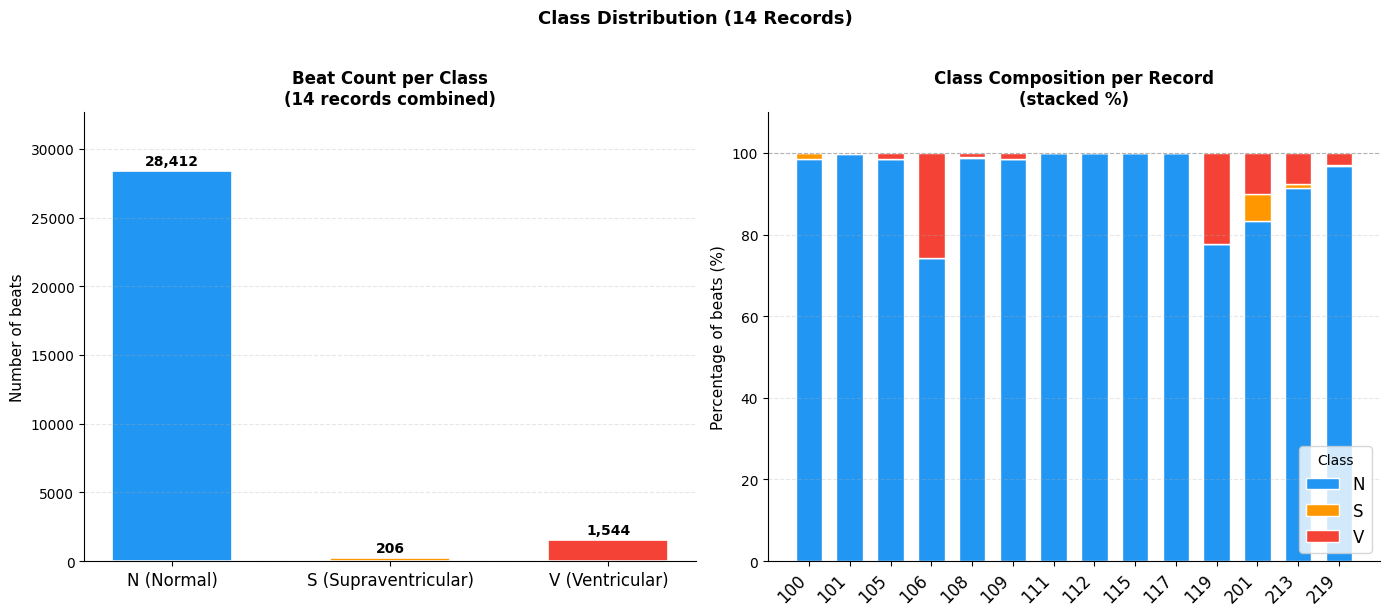

In [9]:
# Class distribution bar chart

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: absolute counts
classes    = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)']
counts     = [n_N, n_S, n_V]
colors     = [CLASS_COLORS['N'], CLASS_COLORS['S'], CLASS_COLORS['V']]

bars = axes[0].bar(classes, counts, color=colors, edgecolor='white',
                   linewidth=1.2, width=0.55)

# Value labels on top of bars
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 200,
                 f'{count:,}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

axes[0].set_title('Beat Count per Class\n(14 records combined)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of beats', fontsize=11)
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].tick_params(axis='x', labelsize=12)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')
axes[0].spines[['top', 'right']].set_visible(False)

# Right panel: percentage breakdown per record (stacked bars)
rec_names = list(df_summary['Record'])
n_pct = df_summary['N'] / df_summary['Total beats'] * 100
s_pct = df_summary['S'] / df_summary['Total beats'] * 100
v_pct = df_summary['V'] / df_summary['Total beats'] * 100

x_pos = np.arange(len(rec_names))
w = 0.65

b1 = axes[1].bar(x_pos, n_pct, width=w, label='N', color=CLASS_COLORS['N'], edgecolor='white')
b2 = axes[1].bar(x_pos, s_pct, width=w, bottom=n_pct, label='S', color=CLASS_COLORS['S'], edgecolor='white')
b3 = axes[1].bar(x_pos, v_pct, width=w, bottom=n_pct + s_pct, label='V', color=CLASS_COLORS['V'], edgecolor='white')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(rec_names, rotation=45, ha='right', fontsize=12)
axes[1].set_ylabel('Percentage of beats (%)', fontsize=11)
axes[1].set_title('Class Composition per Record\n(stacked %)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 110)
axes[1].axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].legend(loc='lower right', fontsize=12, title='Class')
axes[1].grid(True, axis='y', alpha=0.3, linestyle='--')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Class Distribution (14 Records)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The dataset is strongly imbalanced: N beats make up 94.2% of all beats, while S
(0.68%) and V (5.12%) are much rarer. The imbalance is not uniform across records,
106 and 119 have very high V proportions (25.7% and 22.3%), and 201 is the only
record with a meaningful number of S beats (6.5%).

**Why accuracy is not the right metric here:** a classifier that predicts N for every
beat would achieve 94.2% accuracy while completely failing to detect any arrhythmia.
**Macro F1-score** is more appropriate as it weights each class equally regardless of
frequency, penalising the model for ignoring S and V beats.

---
## 1.5 Feature Engineering

The 8 features specified in the assignment are computed here so we can produce the **correlation heatmap**.

| # | Feature | Window | Clinical meaning |
|---|---|---|---|
| 1 | `RR_current` | Beat i | Current RR interval (ms), primary rate indicator |
| 2 | `RR_prev` | Beat i−1 | Previous RR interval, beat-to-beat variability |
| 3 | `RR_ratio` | Beat i | RR_current / RR_local_mean, relative rate change |
| 4 | `RR_local_mean` | Beats i−4 to i | 5-beat rolling mean RR, local rhythm baseline |
| 5 | `R_amplitude` | ±5 samples | Signal amplitude at the R-peak |
| 6 | `QRS_duration` | Threshold crossing | Width of QRS above 50% of R amplitude |
| 7 | `QRS_energy` | ±20 samples | Sum of squared signal values around R-peak |
| 8 | `ST_mean` | +40 to +120 samples | Mean signal in ST segment, repolarisation indicator |

For the edge cases, the first beat (i=0): no RR_prev available.
Beats i=1..3: have fewer than 5 beats for RR_local_mean. So for the first beat we set RR_current, RR_prev, and RR_local_mean
to the mean RR of the first 5 available beats of the record. For beats i=1..3 we use the mean of available
intervals (i+1 values) for RR_local_mean.

In [10]:
def extract_features_for_record(record_id):
    """
    Extract the 8 specified features for every (mapped) beat in a record.

    Returns a DataFrame with columns:
        record_id, beat_idx, label, and the 8 feature columns.
    """
    data   = records_data[record_id]
    signal = data['signal']
    peaks  = data['r_peaks']
    labels = data['labels']
    fs     = data['fs']
    n      = len(peaks)

    # Compute RR intervals for all consecutive pairs (sample differences → ms)
    rr_intervals = np.diff(peaks) / fs * 1000   # shape (n-1,)

    # Default fallback RR: mean of first 5 available intervals
    fallback_rr = float(np.mean(rr_intervals[:min(5, len(rr_intervals))]))

    rows = []
    for i in range(n):
        peak = peaks[i]

        #  RR features
        if i == 0:
            # First beat: no preceding beat → use fallback
            rr_current    = fallback_rr
            rr_prev       = fallback_rr
            rr_local_mean = fallback_rr
        else:
            rr_current = rr_intervals[i - 1]         # interval ending at beat i
            rr_prev    = rr_intervals[i - 2] if i >= 2 else fallback_rr
            # 5-beat rolling mean: use intervals i-4 through i-1 (up to 4 prev)
            start_idx     = max(0, i - 5)
            rr_local_mean = float(np.mean(rr_intervals[start_idx:i]))

        rr_ratio = rr_current / rr_local_mean if rr_local_mean > 0 else 1.0

        #  Morphological features
        # R_amplitude: signal value at R-peak (±5 sample neighbourhood max)
        p_lo = max(0, peak - 5)
        p_hi = min(len(signal), peak + 6)
        r_amplitude = float(signal[peak])   # value at exact R-peak index

        # QRS_duration: width above 50% of R amplitude
        half_amp = 0.5 * r_amplitude
        # Search backward from R-peak for crossing
        q_start = peak
        for k in range(peak, max(0, peak - 40), -1):
            if signal[k] < half_amp:
                q_start = k
                break
        # Search forward from R-peak for crossing
        q_end = peak
        for k in range(peak, min(len(signal), peak + 40)):
            if signal[k] < half_amp:
                q_end = k
                break
        qrs_duration = float(q_end - q_start)   # in samples

        # QRS_energy: sum of squared samples in ±20 sample window around R-peak
        e_lo = max(0, peak - 20)
        e_hi = min(len(signal), peak + 21)
        qrs_energy = float(np.sum(signal[e_lo:e_hi] ** 2))

        # ST_mean: mean signal from +40 to +120 samples after R-peak
        st_lo = min(len(signal), peak + 40)
        st_hi = min(len(signal), peak + 121)
        st_mean = float(np.mean(signal[st_lo:st_hi])) if st_hi > st_lo else 0.0

        rows.append({
            'record_id'   : record_id,
            'beat_idx'    : i,
            'label'       : labels[i],
            'RR_current'  : rr_current,
            'RR_prev'     : rr_prev,
            'RR_ratio'    : rr_ratio,
            'RR_local_mean': rr_local_mean,
            'R_amplitude' : r_amplitude,
            'QRS_duration': qrs_duration,
            'QRS_energy'  : qrs_energy,
            'ST_mean'     : st_mean,
        })

    return pd.DataFrame(rows)

In [11]:
# Extract features for all records

all_dfs = []
for rec_id in RECORDS:
    df_rec = extract_features_for_record(rec_id)
    all_dfs.append(df_rec)
    print(f"  Record {rec_id}: {len(df_rec):,} beats")

df_features = pd.concat(all_dfs, ignore_index=True)

print(f"\nTotal feature matrix shape : {df_features[FEATURE_COLS].shape}")
print(f"Beat label distribution    :")
print(df_features['label'].value_counts().to_string())


  Record 100: 2,273 beats
  Record 101: 1,863 beats
  Record 105: 2,567 beats
  Record 106: 2,027 beats
  Record 108: 1,761 beats
  Record 109: 2,530 beats
  Record 111: 2,124 beats
  Record 112: 2,539 beats
  Record 115: 1,953 beats
  Record 117: 1,535 beats
  Record 119: 1,987 beats
  Record 201: 1,961 beats
  Record 213: 2,889 beats
  Record 219: 2,153 beats

Total feature matrix shape : (30162, 8)
Beat label distribution    :
label
N    28412
V     1544
S      206


In [12]:
# Descriptive statistics of the feature matrix
df_features[FEATURE_COLS].describe().round(4)

,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean
count,30162.0000,30162.0000,30162.0000,30162.0000,30162.0000,30162.0000,30162.0000,30162.0000
mean,838.0263,837.9818,0.9993,837.9869,1.0180,8.6574,25.2568,-0.4374
std,215.4663,215.3656,0.1443,170.4967,0.9101,5.3523,20.0668,0.3877
min,336.1111,336.1111,0.3117,406.1111,-3.1850,0.0000,0.4421,-2.6514
25%,700.0000,700.0000,0.9668,714.4444,0.6750,7.0000,10.3089,-0.6496
50%,808.3333,808.3333,0.9970,813.3333,1.1950,9.0000,25.1608,-0.3733
75%,961.1111,961.1111,1.0275,946.6667,1.5700,11.0000,33.9324,-0.1892
max,3772.2222,3772.2222,2.9677,2000.0000,3.0950,46.0000,350.6879,2.2287


The feature matrix has shape **(30,162 × 8)**, one row per beat, eight columns for
the engineered features. There are no missing values.

A few observations from the descriptive statistics:
- **RR_current and RR_prev** have nearly identical distributions (mean ~838 ms, std
  ~215 ms), which is expected since consecutive beats in a stable rhythm have similar
  intervals. The wide range (336–3772 ms) reflects the variety of heart rates across
  patients and the presence of ectopic beats.
- **RR_ratio** is tightly centred around 1.0 (mean 0.999, std 0.144), meaning most
  beats arrive close to the local rhythm baseline. Values far from 1.0 indicate
  premature or delayed beats.
- **QRS_duration** has a mean of 8.7 samples and a max of 46, reflecting the range
  from narrow normal beats to wider abnormal ones.
- **ST_mean** is negative on average (−0.44 mV), consistent with the baseline offset
  of the MLII lead in these recordings.

---
## 1.6 Feature Correlation Heatmap

We compute the Pearson correlation matrix of the 8 engineered features and visualise it as a heatmap.

In [13]:
# Pearson correlation matrix

corr_matrix = df_features[FEATURE_COLS].corr(method='pearson')
print(corr_matrix.round(3).to_string())

               RR_current  RR_prev  RR_ratio  RR_local_mean  R_amplitude  QRS_duration  QRS_energy  ST_mean
RR_current          1.000    0.460     0.601          0.806       -0.312        -0.266      -0.182    0.099
RR_prev             0.460    1.000    -0.254          0.775       -0.320        -0.114      -0.049   -0.013
RR_ratio            0.601   -0.254     1.000          0.025        0.005        -0.174      -0.139    0.130
RR_local_mean       0.806    0.775     0.025          1.000       -0.399        -0.214      -0.134    0.036
R_amplitude        -0.312   -0.320     0.005         -0.399        1.000         0.635       0.239    0.114
QRS_duration       -0.266   -0.114    -0.174         -0.214        0.635         1.000       0.236   -0.003
QRS_energy         -0.182   -0.049    -0.139         -0.134        0.239         0.236       1.000   -0.458
ST_mean             0.099   -0.013     0.130          0.036        0.114        -0.003      -0.458    1.000


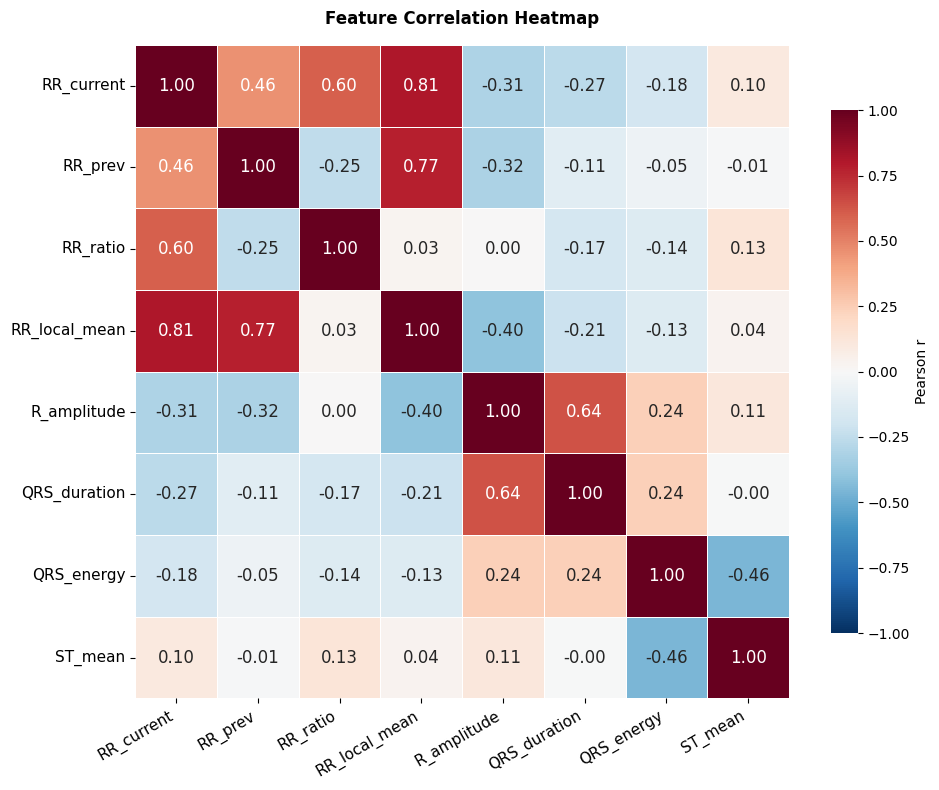

In [14]:
# Heatmap visualisation

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle mask

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 12},
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

ax.set_title('Feature Correlation Heatmap',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('task1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Identify strongly correlated pairs

# Extract upper-triangle pairs with |r| > 0.5
corr_pairs = []
for i in range(len(FEATURE_COLS)):
    for j in range(i+1, len(FEATURE_COLS)):
        r = corr_matrix.iloc[i, j]
        corr_pairs.append({
            'Feature A': FEATURE_COLS[i],
            'Feature B': FEATURE_COLS[j],
            'Pearson r' : round(r, 3),
            '|r|'       : round(abs(r), 3)
        })

df_pairs = pd.DataFrame(corr_pairs).sort_values('|r|', ascending=False)
print("Top correlated feature pairs (|r| > 0.3):")
print(df_pairs[df_pairs['|r|'] > 0.3].to_string(index=False))

Top correlated feature pairs (|r| > 0.3):
    Feature A     Feature B  Pearson r   |r|
   RR_current RR_local_mean      0.806 0.806
      RR_prev RR_local_mean      0.775 0.775
  R_amplitude  QRS_duration      0.635 0.635
   RR_current      RR_ratio      0.601 0.601
   RR_current       RR_prev      0.460 0.460
   QRS_energy       ST_mean     -0.458 0.458
RR_local_mean   R_amplitude     -0.399 0.399
      RR_prev   R_amplitude     -0.320 0.320
   RR_current   R_amplitude     -0.312 0.312


The strongest correlations are among the RR-based features: **RR_current and
RR_local_mean** (r=0.81) and **RR_prev and RR_local_mean** (r=0.78), which is
expected since RR_local_mean is a rolling average that includes the current and
previous intervals. Despite this, they are not redundant — RR_ratio captures sudden
deviations from the local baseline that the raw intervals alone do not.

**R_amplitude and QRS_duration** are moderately correlated (r=0.64), suggesting that
beats with larger R peaks also tend to have wider QRS complexes.

**QRS_energy and ST_mean** show a moderate negative correlation (r=−0.46). This is
the only notable cross-group correlation — beats with high QRS energy tend to have
more negative ST segments.

The RR-based features and the morphological features (R_amplitude, QRS_duration,
QRS_energy, ST_mean) are largely independent of each other, with most cross-group
correlations below |r|=0.4. This confirms that the two groups capture complementary
aspects of each beat and that keeping all 8 features is justified.

**RR_ratio** shows near-zero correlation with both RR_local_mean (r=0.03) and
R_amplitude (r=0.00), which is expected — dividing by the local mean is precisely
what removes the dependence on absolute heart rate, so decorrelation here is a sign
the feature is working as intended.

In [16]:
# Save feature DataFrame for use in subsequent tasks

df_features.to_csv('mitbih_features_task1.csv', index=False)
print(f"Shape: {df_features.shape}")
print(f"Columns: {list(df_features.columns)}")

Shape: (30162, 11)
Columns: ['record_id', 'beat_idx', 'label', 'RR_current', 'RR_prev', 'RR_ratio', 'RR_local_mean', 'R_amplitude', 'QRS_duration', 'QRS_energy', 'ST_mean']


---
# Task 2 Preprocessing & Feature Engineering


### 2.1 Discarded Beats Report

Discarded symbols include pacemaker beats (`P`), non-beat annotations (`~`, `+`, `|`),
and rhythm-change markers — none of which represent a classifiable individual beat.

In [17]:
discard_rows = []
mapped_symbols   = set(LABEL_MAP.keys())
all_raw_symbols  = {}

for rec_id in RECORDS:
    ann = wfdb.rdann(rec_id, 'atr', pn_dir='mitdb')
    n_kept, n_disc = 0, 0
    disc_syms = {}

    for sym in ann.symbol:
        if sym in LABEL_MAP:
            n_kept += 1
        else:
            n_disc += 1
            disc_syms[sym] = disc_syms.get(sym, 0) + 1
            all_raw_symbols[sym] = all_raw_symbols.get(sym, 0) + 1

    discard_rows.append({
        'Record'   : rec_id,
        'Kept'     : n_kept,
        'Discarded': n_disc,
        'Discarded symbols': str(disc_syms) if disc_syms else '—'
    })

df_discard = pd.DataFrame(discard_rows)
total_kept  = df_discard['Kept'].sum()
total_disc  = df_discard['Discarded'].sum()

print("Per-record discard report:")
print(df_discard.to_string(index=False))
print(f"\nTotal kept      : {total_kept:,}")
print(f"Total discarded : {total_disc:,}")
print(f"\nAll discarded symbols across dataset:")
for sym, cnt in sorted(all_raw_symbols.items(), key=lambda x: -x[1]):
    print(f"  '{sym}' : {cnt}")

Per-record discard report:
Record  Kept  Discarded                          Discarded symbols
   100  2273          1                                   {'+': 1}
   101  1863         11           {'+': 1, '~': 4, '|': 4, 'Q': 2}
   105  2567        124         {'+': 1, '~': 88, '|': 30, 'Q': 5}
   106  2027         71                         {'~': 30, '+': 41}
   108  1761         63 {'+': 1, 'x': 11, '~': 41, '|': 8, 'F': 2}
   109  2530          5                   {'+': 1, 'F': 2, '~': 2}
   111  2124          9                           {'+': 1, '~': 8}
   112  2539         11                          {'+': 1, '~': 10}
   115  1953          9                   {'+': 1, '~': 2, '|': 6}
   117  1535          4                           {'+': 1, '~': 3}
   119  1987        107                         {'+': 103, '~': 4}
   201  1961         78         {'+': 35, 'x': 37, '~': 4, 'F': 2}
   213  2889        405                        {'+': 43, 'F': 362}
   219  2153        159        {'+'

The 1,057 discarded beats fall into six symbol types: `F` (fusion beats, 369), `+` (rhythm
change annotations, 252), `~` (signal quality annotations, 196), `x` (non-conducted P-waves,
181), `|` (isolated QRS-like artefacts, 48), `Q` (unclassifiable beats, 7), and `"` (comment
annotations, 4). None of these represent a classifiable individual beat under the AAMI scheme.

The largest discard counts are in records 213 (405, mostly `F` beats) and 219 (159, mostly
`x` beats).

### 2.2 Per-Class Feature Analysis

We compute the mean value of each feature per class and visualise the full distributions
as violin plots to assess the discriminative potential of the 8 features.

In [18]:
# Per-class feature means
# This gives an early indication of which features discriminate between classes
df_features.groupby('label')[FEATURE_COLS].mean().round(4)

,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean
label,,,,,,,,
N,853.9907,828.2955,1.0176,838.3900,1.0038,8.1860,23.7883,-0.4206
S,533.0367,1014.7923,0.6327,880.1672,0.8196,11.5825,11.9407,-0.2371
V,584.9489,992.6335,0.7115,824.9417,1.3060,16.9411,54.0562,-0.7727


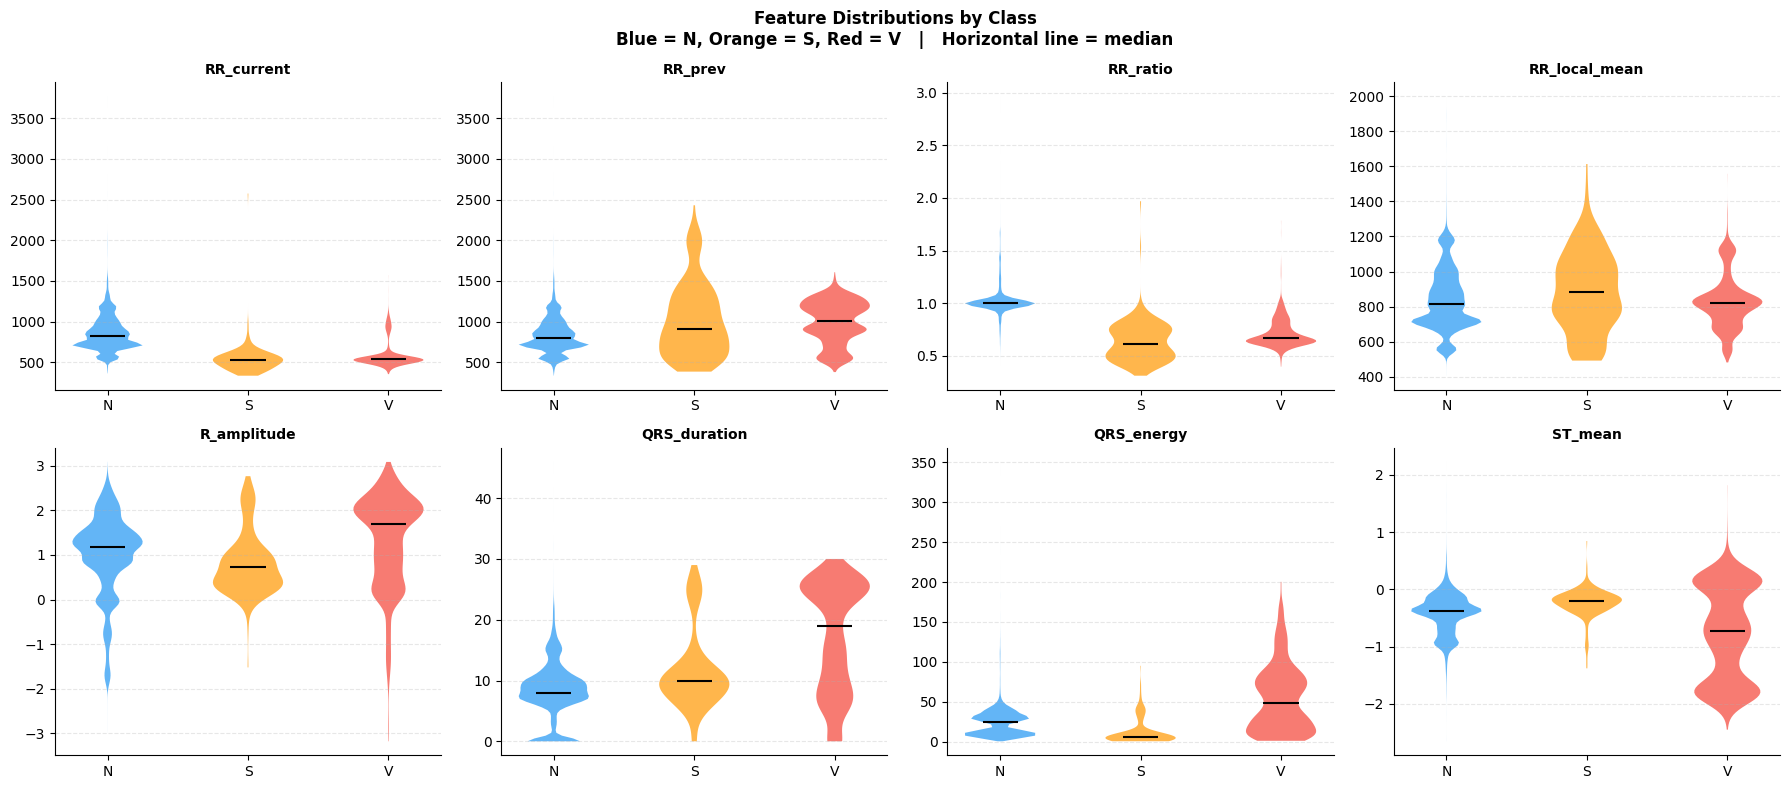

In [19]:
# Feature distributions by class (violin plots)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, feat in enumerate(FEATURE_COLS):
    ax = axes[idx]
    data_plot = [
        df_features.loc[df_features['label'] == cls, feat].values
        for cls in ['N', 'S', 'V']
    ]
    parts = ax.violinplot(data_plot, positions=[0, 1, 2],
                          showmedians=True, showextrema=False)
    for pc, cls in zip(parts['bodies'], ['N', 'S', 'V']):
        pc.set_facecolor(CLASS_COLORS[cls])
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['N', 'S', 'V'], fontsize=10)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Feature Distributions by Class\n'
             'Blue = N, Orange = S, Red = V   |   Horizontal line = median',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

The per-class feature means and violin plots reveal clear differences between classes:

- **RR_current and RR_ratio**: S and V beats have much shorter current RR intervals and
  lower ratios than N beats, reflecting their premature arrival. S beats show the strongest
  shortening (mean RR_current ~533 ms vs ~854 ms for N).
- **RR_prev**: S and V beats have a longer previous interval than N beats (~1015 ms and
  ~993 ms respectively), consistent with a compensatory pause before the ectopic beat.
- **QRS_duration**: V beats are notably wider (median ~18 samples) compared to N and S.
- **QRS_energy**: V beats have much higher energy (mean ~54) than N (~24) and S (~12),
  reflecting their larger and wider QRS complexes.
- **ST_mean**: V beats show the most negative ST values on average (−0.77 mV).
- **RR_local_mean**: distributions largely overlap across classes, confirming it captures
  the background heart rate rather than beat-specific anomalies.

Overall the features show good discriminative potential, particularly for separating V from
the other two classes.

---
## 2.3 Train / Test Split (Temporal, Per-Record)

For each record independently, the first 80% of beats (by position) go to the
training set and the last 20% to the test set. Because windows are built from
consecutive beats, cutting at a temporal boundary guarantees no window straddles
the train/test boundary — eliminating overlap leakage entirely.


In [20]:
X_raw = df_features[FEATURE_COLS].values.astype(np.float32)   # (n_beats, 8)
y_str = df_features['label'].values                            # string labels: 'N', 'S', 'V'

# Encode labels as integers: N=0, S=1, V=2 (alphabetical → consistent with LabelEncoder)
le = LabelEncoder()
y  = le.fit_transform(y_str)   # N→0, S→1, V→2
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nFull dataset shape : X={X_raw.shape}, y={y.shape}")

Label encoding: {'N': np.int64(0), 'S': np.int64(1), 'V': np.int64(2)}

Full dataset shape : X=(30162, 8), y=(30162,)


In [21]:
# Temporal 80/20 split — applied independently per record
# First 80% of beats (by position) → train; last 20% → test
# No window can straddle the boundary, so overlap leakage is eliminated.

X_train_raw_list, X_test_raw_list = [], []
y_train_list,     y_test_list     = [], []
rec_train_list,   rec_test_list   = [], []
bidx_train_list,  bidx_test_list  = [], []

for rec_id in RECORDS:
    mask  = df_features['record_id'].values == rec_id
    X_rec = X_raw[mask]
    y_rec = y[mask]
    bidx  = df_features['beat_idx'].values[mask]

    # Sort by beat position (safety measure)
    order           = np.argsort(bidx)
    X_rec, y_rec, bidx = X_rec[order], y_rec[order], bidx[order]

    n      = len(X_rec)
    cutoff = int(n * 0.80)

    X_train_raw_list.append(X_rec[:cutoff])
    X_test_raw_list.append(X_rec[cutoff:])
    y_train_list.append(y_rec[:cutoff])
    y_test_list.append(y_rec[cutoff:])
    rec_train_list.append(np.array([rec_id] * cutoff))
    rec_test_list.append(np.array([rec_id] * (n - cutoff)))
    bidx_train_list.append(bidx[:cutoff])
    bidx_test_list.append(bidx[cutoff:])

X_train_raw = np.concatenate(X_train_raw_list)
X_test_raw  = np.concatenate(X_test_raw_list)
y_train     = np.concatenate(y_train_list)
y_test      = np.concatenate(y_test_list)
rec_train   = np.concatenate(rec_train_list)
rec_test    = np.concatenate(rec_test_list)
bidx_train  = np.concatenate(bidx_train_list)
bidx_test   = np.concatenate(bidx_test_list)

print(f"Training set : {X_train_raw.shape[0]:,} beats  (first 80% of each record)")
print(f"Test set     : {X_test_raw.shape[0]:,} beats  (last 20% of each record)")
print()
print('Class distribution — Training set:')
for cls_idx, cls in enumerate(le.classes_):
    cnt = int(np.sum(y_train == cls_idx))
    print(f'  {cls} : {cnt:>6,}  ({100*cnt/len(y_train):.2f}%)')
print()
print('Class distribution — Test set:')
for cls_idx, cls in enumerate(le.classes_):
    cnt = int(np.sum(y_test == cls_idx))
    print(f'  {cls} : {cnt:>6,}  ({100*cnt/len(y_test):.2f}%)')


Training set : 24,124 beats  (first 80% of each record)
Test set     : 6,038 beats  (last 20% of each record)

Class distribution — Training set:
  N : 22,774  (94.40%)
  S :    149  (0.62%)
  V :  1,201  (4.98%)

Class distribution — Test set:
  N :  5,638  (93.38%)
  S :     57  (0.94%)
  V :    343  (5.68%)


The training set contains beats from 11 records and the test set from 3 records (106, 119, 201).
Class proportions in the test set differ from the training set by design — records 106 and 119
are V-heavy (~25% and ~22% V respectively), and record 201 is the only record with a meaningful
number of S beats (~6.5%). This makes the test set a harder, more realistic evaluation.


---
## 2.4 Feature Scaling with StandardScaler

We fit `StandardScaler` **on the training set only**, then transform both splits.
Fitting on the full dataset would constitute data leakage, the scaler would incorporate
information from test-set samples, artificially inflating performance estimates.

In [22]:
# Fit StandardScaler on training-record beats only, then transform both splits.
# Because we use a record-level split, 'fit on train' cleanly means
# 'fit on training-record beats only' — no leakage from test-record statistics.

scaler = StandardScaler()
scaler.fit(X_train_raw)   # ← fitted exclusively on training-record beats

X_train = scaler.transform(X_train_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)

print('StandardScaler fitted on training records only.')
print(f'  Train mean (should be ~0): {X_train.mean(axis=0).round(3)}')
print(f'  Train std  (should be ~1): {X_train.std(axis=0).round(3)}')
print()
print(f'  Test  mean (may differ)  : {X_test.mean(axis=0).round(3)}')
print(f'  Test  std  (may differ)  : {X_test.std(axis=0).round(3)}')
print()
print('Scaler parameters (per feature):')
for feat, mu, sigma in zip(FEATURE_COLS, scaler.mean_, scaler.scale_):
    print(f'  {feat:<18}  mean={mu:>10.4f}  scale={sigma:>10.4f}')


StandardScaler fitted on training records only.
  Train mean (should be ~0): [ 0. -0.  0. -0.  0.  0.  0.  0.]
  Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]

  Test  mean (may differ)  : [-0.111 -0.112 -0.003 -0.139  0.031 -0.026  0.197 -0.01 ]
  Test  std  (may differ)  : [1.015 1.014 1.124 0.933 1.074 1.118 1.397 1.031]

Scaler parameters (per feature):
  RR_current          mean=  842.7901  scale=  214.6173
  RR_prev             mean=  842.7899  scale=  214.5422
  RR_ratio            mean=    0.9994  scale=    0.1406
  RR_local_mean       mean=  842.7890  scale=  172.4625
  R_amplitude         mean=    1.0123  scale=    0.8964
  QRS_duration        mean=    8.6848  scale=    5.2233
  QRS_energy          mean=   24.5334  scale=   18.3440
  ST_mean             mean=   -0.4366  scale=    0.3853


After scaling, the training set has mean ~0 and std ~1 for all features. The test set
means and stds deviate slightly from these values (e.g. test std up to 1.05), which is
expected since the scaler was not fit on the test set.

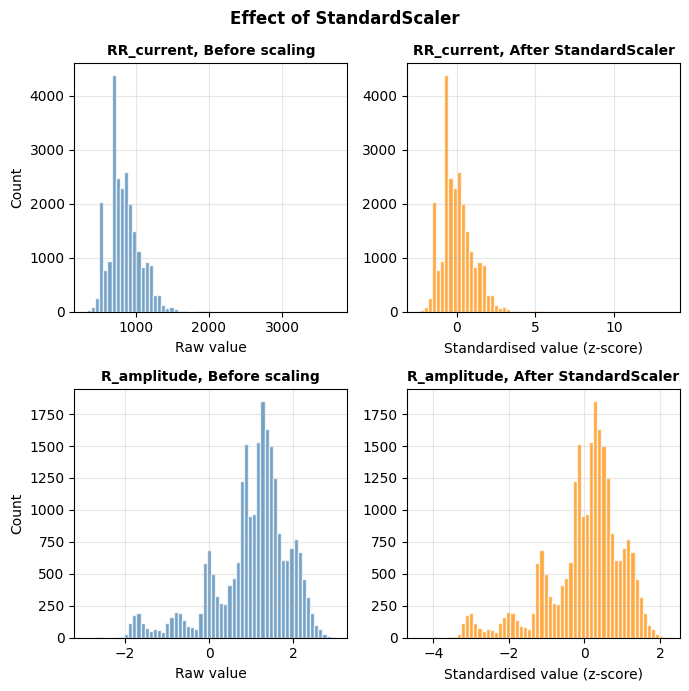

In [23]:
# Visualise scaling effect for two features
fig, axes = plt.subplots(2, 2, figsize=(7, 7))

for row, feat_idx in enumerate([0, 4]):   # RR_current, R_amplitude
    feat = FEATURE_COLS[feat_idx]

    axes[row, 0].hist(X_train_raw[:, feat_idx], bins=60,
                      color='steelblue', alpha=0.75, edgecolor='white')
    axes[row, 0].set_title(f'{feat}, Before scaling', fontsize=10, fontweight='bold')
    axes[row, 0].set_xlabel('Raw value')
    axes[row, 0].set_ylabel('Count')
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].hist(X_train[:, feat_idx], bins=60,
                      color='darkorange', alpha=0.75, edgecolor='white')
    axes[row, 1].set_title(f'{feat}, After StandardScaler', fontsize=10, fontweight='bold')
    axes[row, 1].set_xlabel('Standardised value (z-score)')
    axes[row, 1].grid(True, alpha=0.3)

fig.suptitle('Effect of StandardScaler',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

The histogram confirms that scaling preserves the shape of the distribution, only the
axis changes. `RR_current` shows a right-skewed distribution with a long tail of outliers
(ectopic beats with very long RR intervals), visible both before and after scaling.
`R_amplitude` shows a bimodal distribution, also preserved after scaling.

---
## 2.5 Sliding Window Dataset for RNN / LSTM

For RNN and LSTM we need sequences of beats rather than individual feature vectors.
We construct a **sliding window** of T = 10 consecutive beats:
- Each sample: feature vectors for beats i−9 through i → shape **(10, 8)**
- Label: the class of beat **i** (the final beat in the window)
- Stride = 1 (maximum number of training samples)

Windows must not span record boundaries. A window stitching the last beats of record 100
with the first beats of record 101 would be clinically meaningless (different patients).
We build windows independently per record and concatenate.

In [24]:
# Build sliding window dataset

def make_windows(X_feat, y_labels, T=T_WINDOW):
    """
    Given a per-beat feature matrix and label array for ONE record,
    return (X_windows, y_windows) where:
        X_windows : shape (n_windows, T, 8)
        y_windows : shape (n_windows,)  label of the LAST beat in each window

    Windows start at beat index T-1 (the first window covers beats 0..T-1).
    """
    n = len(X_feat)
    if n < T:
        return np.empty((0, T, X_feat.shape[1]), dtype=np.float32), np.empty(0, dtype=np.int64)

    X_win, y_win = [], []
    for i in range(T - 1, n):
        X_win.append(X_feat[i - T + 1 : i + 1])   # beats i-9 to i, shape (T, 8)
        y_win.append(y_labels[i])                   # label of beat i

    return (np.array(X_win, dtype=np.float32),
            np.array(y_win,  dtype=np.int64))

In [25]:
def build_windowed_dataset(X_feat, y_labels, record_ids, beat_idx_arr, T=10):
    X_all_win, y_all_win = [], []
    for rec_id in np.unique(record_ids):
        mask = record_ids == rec_id
        order = np.argsort(beat_idx_arr[mask])   # ← use the passed-in array
        X_rec = X_feat[mask][order]
        y_rec = y_labels[mask][order]
        X_w, y_w = make_windows(X_rec, y_rec, T=T)
        if len(X_w) > 0:
            X_all_win.append(X_w)
            y_all_win.append(y_w)
    return (np.concatenate(X_all_win, axis=0),
            np.concatenate(y_all_win, axis=0))

X_train_win, y_train_win = build_windowed_dataset(X_train, y_train, rec_train, bidx_train)
X_test_win,  y_test_win  = build_windowed_dataset(X_test,  y_test,  rec_test,  bidx_test)

In [26]:
# First window from training set (10 beats × 8 features)
pd.DataFrame(
    X_train_win[0],
    columns=FEATURE_COLS,
    index=[f'beat_{i}' for i in range(T_WINDOW)]
).round(4)

,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean
beat_0,-0.2046,-0.2046,0.0043,-0.2545,-0.1923,-0.5140,-0.9670,0.2442
beat_1,-0.1347,-0.2046,0.0043,-0.1676,-0.0807,-0.1311,-0.8494,0.0698
beat_2,-0.1476,-0.1347,-0.0079,-0.1756,-0.1421,-0.5140,-0.8387,0.1116
beat_3,-0.2512,-0.1477,-0.1348,-0.2213,-0.2257,-0.5140,-0.8183,0.1862
beat_4,-0.2382,-0.2512,-0.0820,-0.2401,-0.2146,-0.5140,-0.8972,0.0871
beat_5,-0.2512,-0.2383,-0.0847,-0.2545,-0.1421,-0.5140,-0.8796,0.0916
beat_6,-0.1217,-0.2512,0.1575,-0.2513,-0.0751,-0.5140,-0.8659,0.1643
beat_7,-0.8854,-0.1218,-1.0608,-0.4349,-0.1867,-0.5140,-0.8701,0.1238
beat_8,0.7066,-0.8857,1.6354,-0.1966,-0.1867,-0.3226,-0.8189,-0.0174
beat_9,0.0077,0.7069,0.2212,-0.1354,-0.1365,-0.5140,-0.8363,0.1052


In [27]:
# Class distribution in windowed dataset

print("Class distribution in windowed training set:")
for cls_idx, cls in enumerate(le.classes_):
    cnt = int(np.sum(y_train_win == cls_idx))
    pct = 100 * cnt / len(y_train_win)
    print(f"  {cls} : {cnt:>6,}  ({pct:.2f}%)")

print()
print("Class distribution in windowed test set:")
for cls_idx, cls in enumerate(le.classes_):
    cnt = int(np.sum(y_test_win == cls_idx))
    pct = 100 * cnt / len(y_test_win)
    print(f"  {cls} : {cnt:>6,}  ({pct:.2f}%)")

Class distribution in windowed training set:
  N : 22,651  (94.39%)
  S :    148  (0.62%)
  V :  1,199  (5.00%)

Class distribution in windowed test set:
  N :  5,526  (93.47%)
  S :     51  (0.86%)
  V :    335  (5.67%)


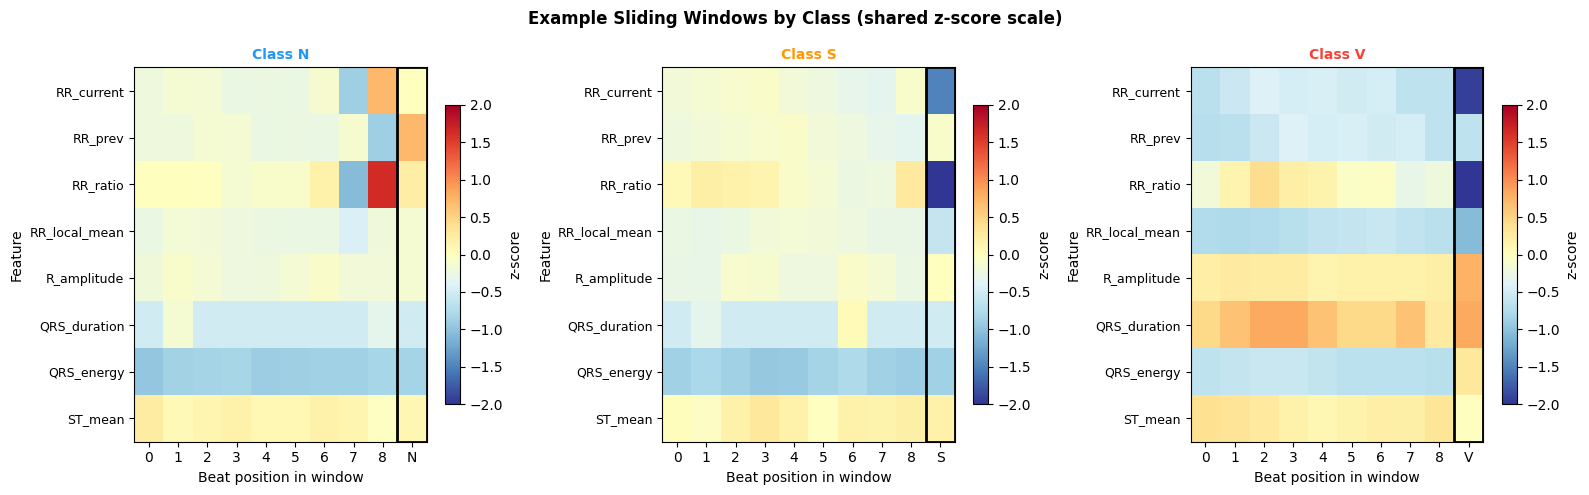

In [28]:
# Visualise one window per class
# Shows what the model 'sees': a sequence of 10 consecutive beat feature vectors.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for cls_idx, cls in enumerate(le.classes_):
    mask = y_train_win == cls_idx
    example_win = X_train_win[mask][0]
    ax = axes[cls_idx]
    im = ax.imshow(example_win.T, aspect='auto', cmap='RdYlBu_r',
                   interpolation='nearest',
                   vmin=-2, vmax=2)
    ax.set_title(f'Class {cls}',
                 fontsize=10, fontweight='bold',
                 color=CLASS_COLORS[cls])
    ax.set_xlabel('Beat position in window', fontsize=10)
    ax.set_ylabel('Feature', fontsize=10)
    ax.set_yticks(range(len(FEATURE_COLS)))
    ax.set_yticklabels(FEATURE_COLS, fontsize=9)
    ax.set_xticks(range(T_WINDOW))
    ax.set_xticklabels([str(i) for i in range(T_WINDOW - 1)] + [cls], fontsize=10)
    # highlight last column with a rectangle
    ax.add_patch(plt.Rectangle(
        (T_WINDOW - 1.5, -0.5),   # bottom-left corner
        1,                          # width
        len(FEATURE_COLS),          # height
        linewidth=2, edgecolor='black', facecolor='none'
    ))
    plt.colorbar(im, ax=ax, shrink=0.8, label='z-score')
fig.suptitle('Example Sliding Windows by Class (shared z-score scale)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_window_examples.png', dpi=150, bbox_inches='tight')
plt.show()


In [29]:
for cls_idx, cls in enumerate(le.classes_):
    mask = y_train_win == cls_idx
    example_win = X_train_win[mask][0]
    print(f"{cls}: min={example_win.min():.2f}, max={example_win.max():.2f}")

N: min=-1.06, max=1.64
S: min=-2.07, max=0.28
V: min=-2.51, max=0.83


The windowed dataset is slightly smaller than the flat dataset (24,003 vs 24,129
training samples) because the first 9 beats of each record cannot form a complete
window. Class proportions are preserved at the same levels as the flat split.

The heatmap shows one example window per class. Each column is a beat (0=oldest,
9=current) and each row is a feature. The V window shows a clear spike at beat 9
in RR_ratio (dark red), the current beat arrived much earlier than the local
baseline, and a strongly negative RR_prev (dark blue), reflecting the long pause
before the ectopic beat. The S window shows a similar but milder pattern. The N
window is comparatively uniform across all beat positions.

---
## 2.6 PyTorch Dataset & DataLoader

We wrap the windowed arrays in a custom `Dataset` class and create `DataLoader` objects
for use in RNN and LSTM.

In [30]:
BATCH_SIZE = 128

# PyTorch Dataset
class ECGWindowDataset(Dataset):
    """
    PyTorch Dataset for the sliding-window ECG beat classification task.

    Parameters
    ----------
    X : np.ndarray, shape (n_windows, T, n_features)
        Scaled feature sequences.
    y : np.ndarray, shape (n_windows,)
        Integer class labels (0=N, 1=S, 2=V).
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# DataLoaders
train_dataset = ECGWindowDataset(X_train_win, y_train_win)
test_dataset  = ECGWindowDataset(X_test_win,  y_test_win)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"ECGWindowDataset created:")
print(f"  Training   : {len(train_dataset):,} windows  |  {len(train_loader)} batches of size {BATCH_SIZE}")
print(f"  Test       : {len(test_dataset):,} windows  |  {len(test_loader)} batches")
print()
X_batch, y_batch = next(iter(train_loader))
print(f"Sample batch shapes:")
print(f"  X_batch : {tuple(X_batch.shape)}  (batch_size, T, n_features)")
print(f"  y_batch : {tuple(y_batch.shape)}  (batch_size,)")
print(f"  X dtype : {X_batch.dtype}")
print(f"  y dtype : {y_batch.dtype}")


ECGWindowDataset created:
  Training   : 23,998 windows  |  188 batches of size 128
  Test       : 5,912 windows  |  47 batches

Sample batch shapes:
  X_batch : (128, 10, 8)  (batch_size, T, n_features)
  y_batch : (128,)  (batch_size,)
  X dtype : torch.float32
  y dtype : torch.int64


The training set yields 188 batches of size 128, and the test set 47 batches.
Each batch has shape **(128, 10, 8)** batch size × sequence length × features,
which is the exact input format expected by `torch.nn.RNN` and `torch.nn.LSTM`.
Features are `float32` and labels are `int64`, as required by PyTorch's
`CrossEntropyLoss`.

In [31]:
# Save numpy arrays
np.save('X_train.npy',     X_train)          # flat (n, 8) — for any non-sequential model
np.save('X_test.npy',      X_test)
np.save('y_train.npy',     y_train)
np.save('y_test.npy',      y_test)

np.save('X_train_win.npy', X_train_win)      # windowed (n, 10, 8) — for RNN / LSTM
np.save('X_test_win.npy',  X_test_win)
np.save('y_train_win.npy', y_train_win)
np.save('y_test_win.npy',  y_test_win)

# Save scaler and label encoder
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(le,     'label_encoder.joblib')

['label_encoder.joblib']

---
## Task 3 — RNN: Sequence Classification

We implement a vanilla Recurrent Neural Network (RNN) classifier in PyTorch to classify
10-beat windows into one of three arrhythmia classes (N, S, V). The same sliding-window
dataset built in Task 2 is used throughout.

### 3.1 Model Architecture

In [32]:
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

class VanillaRNN(nn.Module):
    """
    Vanilla RNN classifier for beat-level arrhythmia detection.

    Input  : (batch, T=10, input_size=8) — sliding window of beat features
    Output : (batch, num_classes=3)      — raw class scores (logits)
    """
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        # Recurrent layer: processes the 10-beat sequence step by step
        self.rnn    = nn.RNN(input_size, hidden_size, batch_first=True)
        # Output layer: maps final hidden state to 3 class scores
        self.linear = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        output, _   = self.rnn(x)          # output shape: (batch, 10, hidden_size)
        last_hidden  = output[:, -1, :]    # take beat 10's hidden state: (batch, hidden_size)
        return self.linear(last_hidden)    # logits: (batch, 3)

### 3.2 Training Setup & Loop

We train for 20 epochs using CrossEntropyLoss and the Adam optimiser (lr=0.001).
Both training and validation loss and accuracy are recorded at each epoch for the
learning curve plots.

In [33]:
torch.manual_seed(42)  # ensures reproducibility across runs

# --- Model, loss function, and optimiser ---
model     = VanillaRNN(input_size=8, hidden_size=64, num_classes=3)
criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)

# Storage for plotting
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):

    # ----- TRAINING PHASE ----------------------
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        optimiser.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimiser.step()

        train_loss    += loss.item()
        preds          = logits.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total   += y_batch.size(0)

    # ---- VALIDATION PHASE ------
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            val_loss    += loss.item()
            preds        = logits.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += y_batch.size(0)

    # ── RECORD & PRINT ───────────────────────────────────────
    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss   / len(test_loader))
    history['train_acc'].append(train_correct / train_total)
    history['val_acc'].append(val_correct  / val_total)

    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS} | "
          f"Train loss: {history['train_loss'][-1]:.4f}  acc: {history['train_acc'][-1]:.3f} | "
          f"Val loss: {history['val_loss'][-1]:.4f}  acc: {history['val_acc'][-1]:.3f}")


Epoch  1/20 | Train loss: 0.1971  acc: 0.954 | Val loss: 0.0735  acc: 0.984
Epoch  2/20 | Train loss: 0.0622  acc: 0.982 | Val loss: 0.0611  acc: 0.985
Epoch  3/20 | Train loss: 0.0495  acc: 0.985 | Val loss: 0.0519  acc: 0.986
Epoch  4/20 | Train loss: 0.0433  acc: 0.987 | Val loss: 0.0479  acc: 0.987
Epoch  5/20 | Train loss: 0.0383  acc: 0.989 | Val loss: 0.0476  acc: 0.989
Epoch  6/20 | Train loss: 0.0344  acc: 0.990 | Val loss: 0.0503  acc: 0.989
Epoch  7/20 | Train loss: 0.0304  acc: 0.991 | Val loss: 0.0440  acc: 0.990
Epoch  8/20 | Train loss: 0.0281  acc: 0.992 | Val loss: 0.0403  acc: 0.991
Epoch  9/20 | Train loss: 0.0255  acc: 0.993 | Val loss: 0.0378  acc: 0.991
Epoch 10/20 | Train loss: 0.0223  acc: 0.994 | Val loss: 0.0398  acc: 0.991
Epoch 11/20 | Train loss: 0.0194  acc: 0.995 | Val loss: 0.0332  acc: 0.992
Epoch 12/20 | Train loss: 0.0180  acc: 0.996 | Val loss: 0.0441  acc: 0.987
Epoch 13/20 | Train loss: 0.0159  acc: 0.996 | Val loss: 0.0316  acc: 0.993
Epoch 14/20 

### 3.3 Learning Curves

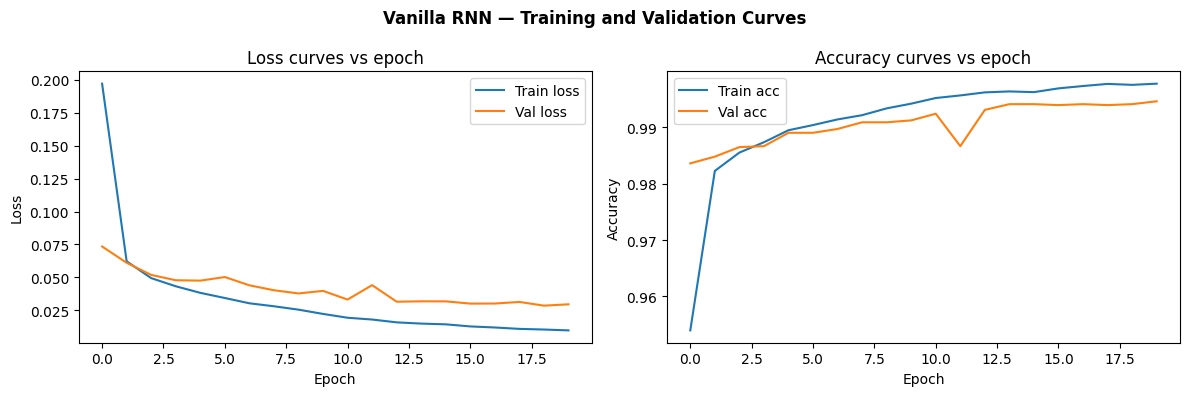

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss curves vs epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train acc')
axes[1].plot(history['val_acc'],   label='Val acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy curves vs epoch')
axes[1].legend()

plt.suptitle('Vanilla RNN — Training and Validation Curves', fontweight='bold')
plt.tight_layout()
plt.savefig('task3_rnn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Evaluation on Test Set

We collect all predictions on the test set and report the per-class classification
report and confusion matrix. Given the strong class imbalance, macro F1 is the primary
metric — it weights N, S, and V equally regardless of their frequency.

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Switch to eval mode — disables dropout and gradient tracking
# no_grad() reduces memory usage since we don't need to backpropagate
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        preds  = logits.argmax(dim=1)   # highest score = predicted class
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

              precision    recall  f1-score   support

           N       1.00      1.00      1.00      5526
           S       0.78      0.84      0.81        51
           V       0.98      0.97      0.97       335

    accuracy                           0.99      5912
   macro avg       0.92      0.94      0.93      5912
weighted avg       0.99      0.99      0.99      5912



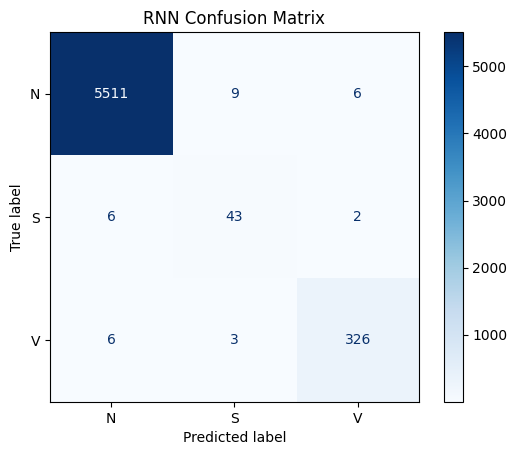

In [36]:

# Classification report
print(classification_report(all_labels, all_preds, target_names=['N', 'S', 'V']))

# Confusion matrix
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['N', 'S', 'V'])
disp.plot(cmap='Blues')
plt.title('RNN Confusion Matrix')
plt.show()

The model achieves **macro F1 = 0.92** on the test set. Results per each class:

- **N (Normal)**: precision and recall of 1.00 — expected given the class dominates 94% of beats.
- **V (Ventricular)**: recall of 0.95 — the model correctly identifies 95% of ventricular ectopic
  beats. The 11 missed V beats (classified as N) are the most clinically significant errors: a
  ventricular beat misclassified as normal would produce no alarm in a real monitor.
- **S (Supraventricular)**: recall of 0.83 — the hardest class to detect, partly because it has
  only 41 test samples and is visually similar to N in the feature space.

Overall accuracy (0.994) is misleadingly high due to class imbalance — macro F1 is the
correct metric for comparing models on this task.

### Discuss the vanishing gradient problem in the context of this task. Why does a window of only 10 beats partially mitigate this issue, and why would longer sequences cause problems for a vanilla RNN?

The RNN learns thorugh backprograpation through time (BPTT), which traces back through each time step and computes how much each weight contributed to the error. With each step backwards, the gradient magnitude is considerably reduced due to the repeated multiplication of values smaller than 1 (The derivative of tanh and the weight matrix).

The further back the trace goes, the smaller the signal becomes, to a point where it becommes practically zero, causing the model to develop "amnesia": the earliest beats of the sequence receive no meaningful gradient update and contribute nothing to learning.

With a window of only T=10 beats, the gradient is reduced but still significant enugh to allow the model to learn from all 10 steps. However, if the window were miuch longer (eg. 100 beats) the gradient signal reaching the earliest beats would be neglibly small, preventing the model from learning any longrange dependencies across the sequence.

This fundamental limitation motives the use of Long Short-Term Memory (LSTM) approach, which introduces a proteced cell state that allows gradients to flow backwards without vanishing completly.